# 05A — Lassa Hybrid Mutation Scoring (Reference + Alignment + ESM-2)

This notebook computes a **mutation landscape for Lassa virus** using:

- A curated **Lassa reference protein** sequence
- A multiple sequence alignment (MSA) of reference + all Lassa sequences
- **ESM-2 embeddings** (780 × 1280) from `lassa_embeddings.pt`
- Hybrid scores per reference position:
  - Conservation & entropy (alignment-based)
  - BLOSUM62 substitution penalty (biochemical)
  - Optional embedding distance (structure/semantics)

Outputs:
- `Lassa_site_scores_reference_based.csv`: per-reference-position scores
- `Lassa_mutation_scores_reference_based.csv`: per-substitution scores (A→V, A→D, …)
- High-level plots for **critical sites**, **hotspots**, and **mutation impact distributions**.


In [1]:
import os
import math
import time
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from Bio import SeqIO
import torch

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# IMPORTANT: If you see NumPy 1.x vs 2.x warnings/crashes:
#   In your environment run:  pip install "numpy<2"
#   Then restart the Jupyter kernel.
# -------------------------------------------------------------

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Base data directory (adjust if needed)
DATA_BASE = Path("/Users/user/data")

# Lassa-specific paths
REF_FASTA  = DATA_BASE / "Reference/Lassa_Reference_Sequence.fasta"   # 1 sequence
DATA_FASTA = DATA_BASE / "processed/lassa_cleaned.fasta"              # 780 sequences
EMB_PT     = DATA_BASE / "embeddings/lassa_embeddings.pt"             # 780 × 1280
META_CSV   = DATA_BASE / "embeddings/lassa_metadata.csv"              # 780 rows

# Outputs
OUT_DIR = DATA_BASE / "results/lassa_step05A"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# MSA temporary files (reference + dataset, and aligned output)
ALN_COMBINED_FASTA = DATA_BASE / "interim/lassa_ref_plus_dataset.fasta"
ALN_OUT            = DATA_BASE / "interim/lassa_with_reference_aligned.fasta"
ALN_COMBINED_FASTA.parent.mkdir(parents=True, exist_ok=True)
ALN_OUT.parent.mkdir(parents=True, exist_ok=True)

print("REF exists :", REF_FASTA.exists(), REF_FASTA)
print("DATA exists:", DATA_FASTA.exists(), DATA_FASTA)
print("EMB exists :", EMB_PT.exists(), EMB_PT)
print("META exists:", META_CSV.exists(), META_CSV)
print("OUT_DIR:", OUT_DIR)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/user/miniconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/user/miniconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/user/miniconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/Users/user

REF exists : True /Users/user/data/Reference/Lassa_Reference_Sequence.fasta
DATA exists: True /Users/user/data/processed/lassa_cleaned.fasta
EMB exists : True /Users/user/data/embeddings/lassa_embeddings.pt
META exists: True /Users/user/data/embeddings/lassa_metadata.csv
OUT_DIR: /Users/user/data/results/lassa_step05A


## SECTION 1 – Load and validate (reference, dataset FASTA, metadata, embeddings)

We ensure that:
- Reference FASTA has exactly 1 sequence
- Dataset FASTA and metadata IDs match 1:1
- Embedding rows match metadata rows, and types are consistent.


In [2]:
def read_single_fasta(path: Path):
    recs = list(SeqIO.parse(str(path), "fasta"))
    assert len(recs) == 1, f"Expected exactly 1 sequence in {path}, found {len(recs)}"
    rec = recs[0]
    return rec.id, str(rec.seq).strip()

ref_id, ref_seq = read_single_fasta(REF_FASTA)
print("Reference ID:", ref_id)
print("Reference length:", len(ref_seq))
print("Reference preview:", ref_seq[:60], "...")

Reference ID: sp|P08669|GLYC_LASSJ
Reference length: 491
Reference preview: MGQIVTFFQEVPHVIEEVMNIVLIALSVLAVLKGLYNFATCGLVGLVTFLLLCGRSCTTS ...


### 1.2 – Load Lassa dataset FASTA (expected 780 sequences)


In [3]:
dataset_records = list(SeqIO.parse(str(DATA_FASTA), "fasta"))
print("Dataset sequences:", len(dataset_records))

data_rows = []
for rec in dataset_records:
    seq = str(rec.seq).strip()
    if seq:
        data_rows.append({
            "id": rec.id,
            "sequence": seq,
            "length": len(seq),
        })
dataset_df = pd.DataFrame(data_rows)
dataset_df.head(3)

Dataset sequences: 780


,id,sequence,length
0,X52400|s|LIII|3417,APGILGIDCAFNLLFGKCRNQDGTDCDILPRSSSCYGSDEYCPYCT...,1064
1,OL774861|s|LIII|3371,AQWILGYWIALCTNQTFGVTTFKTHGSDNHHDNECFQGSEVILVDS...,1059
2,MK107965|s|LIII|3407,IYISRRLRILEALFGDQTIRMGQIVTFFQEVPHVIEEVMNIVLIAL...,1097


### 1.3 – Load metadata + embeddings and cross‑check with FASTA


In [4]:
meta = pd.read_csv(META_CSV)
emb = torch.load(EMB_PT, map_location="cpu")

print("Meta:", meta.shape)
print("Emb:", type(emb), emb.shape, emb.dtype)

assert isinstance(emb, torch.Tensor) and emb.ndim == 2
assert len(meta) == emb.shape[0], "Embeddings rows must match metadata rows"
assert set(["id","sequence","embedding_idx"]).issubset(meta.columns)

# IDs must match between dataset FASTA and metadata
fasta_ids = set(dataset_df["id"])
meta_ids = set(meta["id"])
print("ID match:", fasta_ids == meta_ids, "| FASTA:", len(fasta_ids), "| META:", len(meta_ids))

if fasta_ids != meta_ids:
    print("Missing in META (sample):", list(fasta_ids - meta_ids)[:5])
    print("Missing in FASTA (sample):", list(meta_ids - fasta_ids)[:5])
    raise ValueError("FASTA and metadata IDs do not match. Stop and fix before continuing.")

# Reorder meta (and emb) to match dataset_df order by ID
meta = meta.set_index("id").loc[dataset_df["id"]].reset_index()

# embedding_idx should be 0..N-1 in that same order
assert (meta["embedding_idx"].values == np.arange(len(meta))).all(), (
    "embedding_idx is not 0..N-1 after ordering by FASTA IDs. "
    "This suggests the metadata order differs from embeddings order."
)

X = emb.float()
print("✅ FASTA, metadata, embeddings are consistent. X shape:", X.shape)

Meta: (780, 5)
Emb: <class 'torch.Tensor'> torch.Size([780, 1280]) torch.float32
ID match: True | FASTA: 780 | META: 780
✅ FASTA, metadata, embeddings are consistent. X shape: torch.Size([780, 1280])


## SECTION 2 – Alignment with reference (MSA and reference coordinate system)

We align the **reference Lassa sequence + all dataset sequences** using MAFFT, then use the alignment to define **reference positions**:

- `alignment column → reference position` (1‑based)
- Gaps in reference columns are ignored (no reference position).


In [5]:
def have_mafft():
    try:
        r = subprocess.run(["mafft", "--version"], capture_output=True, text=True)
        return r.returncode == 0
    except FileNotFoundError:
        return False

print("MAFFT available:", have_mafft())
if not have_mafft():
    raise RuntimeError(
        "MAFFT not installed.\n"
        "Install for example:\n"
        "  conda install -c bioconda mafft -y\n"
        "or on macOS:\n"
        "  brew install mafft\n"
        "Then restart the kernel."
    )

MAFFT available: True


### 2.1 – Write combined FASTA (reference first, then dataset)

In [6]:
print("Reference:", ref_id, "len:", len(ref_seq))
print("Dataset sequences:", len(dataset_records))

with open(ALN_COMBINED_FASTA, "w") as f:
    # Reference first
    f.write(f">{ref_id}\n{ref_seq}\n")
    # Then all dataset sequences
    for rec in dataset_records:
        seq = str(rec.seq).strip()
        if seq:
            f.write(f">{rec.id}\n{seq}\n")

print("Wrote combined FASTA:", ALN_COMBINED_FASTA, "bytes:", ALN_COMBINED_FASTA.stat().st_size)

Reference: sp|P08669|GLYC_LASSJ len: 491
Dataset sequences: 780
Wrote combined FASTA: /Users/user/data/interim/lassa_ref_plus_dataset.fasta bytes: 842755


### 2.2 – Run MAFFT to create MSA (reference + all Lassa sequences)


In [7]:
if not ALN_OUT.exists():
    cmd = ["mafft", "--auto", str(ALN_COMBINED_FASTA)]
    print("Running:", " ".join(cmd))
    start = time.time()
    with open(ALN_OUT, "w") as f_out:
        p = subprocess.run(cmd, stdout=f_out, stderr=subprocess.PIPE, text=True)
    print("Return code:", p.returncode)
    print("MAFFT stderr tail:\n", "\n".join(p.stderr.splitlines()[-20:]))
    assert ALN_OUT.exists() and ALN_OUT.stat().st_size > 0
    print(f"✅ Alignment saved: {ALN_OUT} ({(time.time()-start)/60:.1f} min)")
else:
    print("✅ Alignment already exists:", ALN_OUT)

Running: mafft --auto /Users/user/data/interim/lassa_ref_plus_dataset.fasta
Return code: 0
MAFFT stderr tail:
 Reallocating..done. *alloclen = 5565

done.

disttbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It tends to insert more gaps into gap-rich regions than previous versions.
To disable this change, add the --leavegappyregion option.

✅ Alignment saved: /Users/user/data/interim/lassa_with_reference_aligned.fasta (1.0 min)


## SECTION 3 – Reference coordinate mapping (alignment → ref position)

We parse the alignment and build:
- `aligned_ref_seq`: reference sequence with gaps
- `dataset_aligned`: aligned sequences for all Lassa isolates
- `aln_to_refpos`: list of reference positions for each alignment column (or `None` if the reference has a gap at that column).


In [8]:
GAP = "-"
AA_SET = set("ACDEFGHIKLMNPQRSTVWY")
AAS = list("ACDEFGHIKLMNPQRSTVWY")

aligned = list(SeqIO.parse(str(ALN_OUT), "fasta"))
assert aligned[0].id == ref_id, "Reference must be first record in alignment"

aln_ref_seq = str(aligned[0].seq)
aln_len = len(aln_ref_seq)
assert all(len(str(r.seq)) == aln_len for r in aligned), "All aligned sequences must have same length"

dataset_aligned = [str(r.seq) for r in aligned[1:]]  # exclude reference
print("Aligned dataset sequences:", len(dataset_aligned))
print("Alignment length:", aln_len)

# mapping: alignment column -> reference position (1-based), None if ref has gap at that column
aln_to_refpos = [None] * aln_len
ref_pos = 0
for i, ch in enumerate(aln_ref_seq):
    if ch != GAP:
        ref_pos += 1
        aln_to_refpos[i] = ref_pos

assert ref_pos == len(ref_seq), "Reference positions in alignment must equal reference length"
print("✅ Built aln_to_refpos mapping. ref length:", ref_pos)

Aligned dataset sequences: 780
Alignment length: 3269
✅ Built aln_to_refpos mapping. ref length: 491


## SECTION 4 – Site-level scores: conservation & entropy (Lassa)

For each reference position we compute:
- Gap rate across Lassa alignment
- Non-gap count (usable sequences)
- Consensus AA and conservation
- Shannon entropy over AA frequencies
- A coarse site category: **Critical / Conserved / Hotspot / MostlyGap / Intermediate**.


In [9]:
def shannon_entropy(counts: dict):
    total = sum(counts.values())
    if total == 0:
        return 0.0
    ent = 0.0
    for c in counts.values():
        p = c / total
        ent -= p * math.log2(p)
    return ent

rows = []
N = len(dataset_aligned)

for aln_i in range(aln_len):
    refpos = aln_to_refpos[aln_i]
    if refpos is None:
        continue

    ref_aa = aln_ref_seq[aln_i]
    col = [s[aln_i] for s in dataset_aligned]
    counts_all = Counter(col)

    gap_count = counts_all.get(GAP, 0)
    aa_counts = {aa: c for aa, c in counts_all.items() if aa in AA_SET}
    total_aa = sum(aa_counts.values())

    if total_aa == 0:
        consensus = "-"
        conservation = 0.0
        entropy = 0.0
        top_aas = ""
    else:
        consensus, cons_count = max(aa_counts.items(), key=lambda x: x[1])
        conservation = cons_count / total_aa
        entropy = shannon_entropy(aa_counts)
        top = sorted(aa_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        top_aas = ";".join([f"{a}:{c}" for a, c in top])

    rows.append({
        "ref_pos": int(refpos),
        "ref_aa": ref_aa,
        "consensus_aa": consensus,
        "gap_rate": gap_count / N,
        "nongap_count": int(total_aa),
        "conservation": float(conservation),
        "entropy": float(entropy),
        "top_aas": top_aas,
    })

site_df = pd.DataFrame(rows).sort_values("ref_pos").reset_index(drop=True)
print(site_df.shape)
site_df.head(5)

(491, 8)


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas
0,1,M,M,0.487179,400,0.675000,1.566804,M:270;V:75;S:17;E:15;P:10
1,2,G,G,0.484615,402,0.850746,1.061568,G:342;K:12;R:12;S:11;W:10
2,3,Q,Q,0.484615,402,0.684080,1.623073,Q:275;F:68;C:15;E:12;L:11
3,4,I,I,0.478205,407,0.879607,0.859922,I:358;P:15;K:10;T:8;L:5
4,5,V,I,0.365385,495,0.404040,2.685139,I:200;K:91;V:77;L:38;S:19


### 4.1 – Label sites: Critical / Hotspot / etc. (Lassa)


In [10]:
entropy_hotspot_threshold = site_df["entropy"].quantile(0.90)

def site_category(row):
    if row["gap_rate"] > 0.5:
        return "MostlyGap"
    if row["conservation"] >= 0.95 and row["gap_rate"] <= 0.10:
        return "Critical"
    if row["conservation"] >= 0.80:
        return "Conserved"
    if row["entropy"] >= entropy_hotspot_threshold or row["conservation"] <= 0.50:
        return "Hotspot"
    return "Intermediate"

site_df["site_category"] = site_df.apply(site_category, axis=1)
print(site_df["site_category"].value_counts())
site_df.head(5)

site_category
Intermediate    200
Hotspot         171
MostlyGap        84
Conserved        34
Critical          2
Name: count, dtype: int64


,ref_pos,ref_aa,consensus_aa,gap_rate,nongap_count,conservation,entropy,top_aas,site_category
0,1,M,M,0.487179,400,0.675000,1.566804,M:270;V:75;S:17;E:15;P:10,Intermediate
1,2,G,G,0.484615,402,0.850746,1.061568,G:342;K:12;R:12;S:11;W:10,Conserved
2,3,Q,Q,0.484615,402,0.684080,1.623073,Q:275;F:68;C:15;E:12;L:11,Intermediate
3,4,I,I,0.478205,407,0.879607,0.859922,I:358;P:15;K:10;T:8;L:5,Conserved
4,5,V,I,0.365385,495,0.404040,2.685139,I:200;K:91;V:77;L:38;S:19,Hotspot


### 4.2 – Plot site‑level conservation & entropy (Lassa)


Saved: /Users/user/data/results/lassa_step05A/figures/lassa_site_conservation_entropy.png


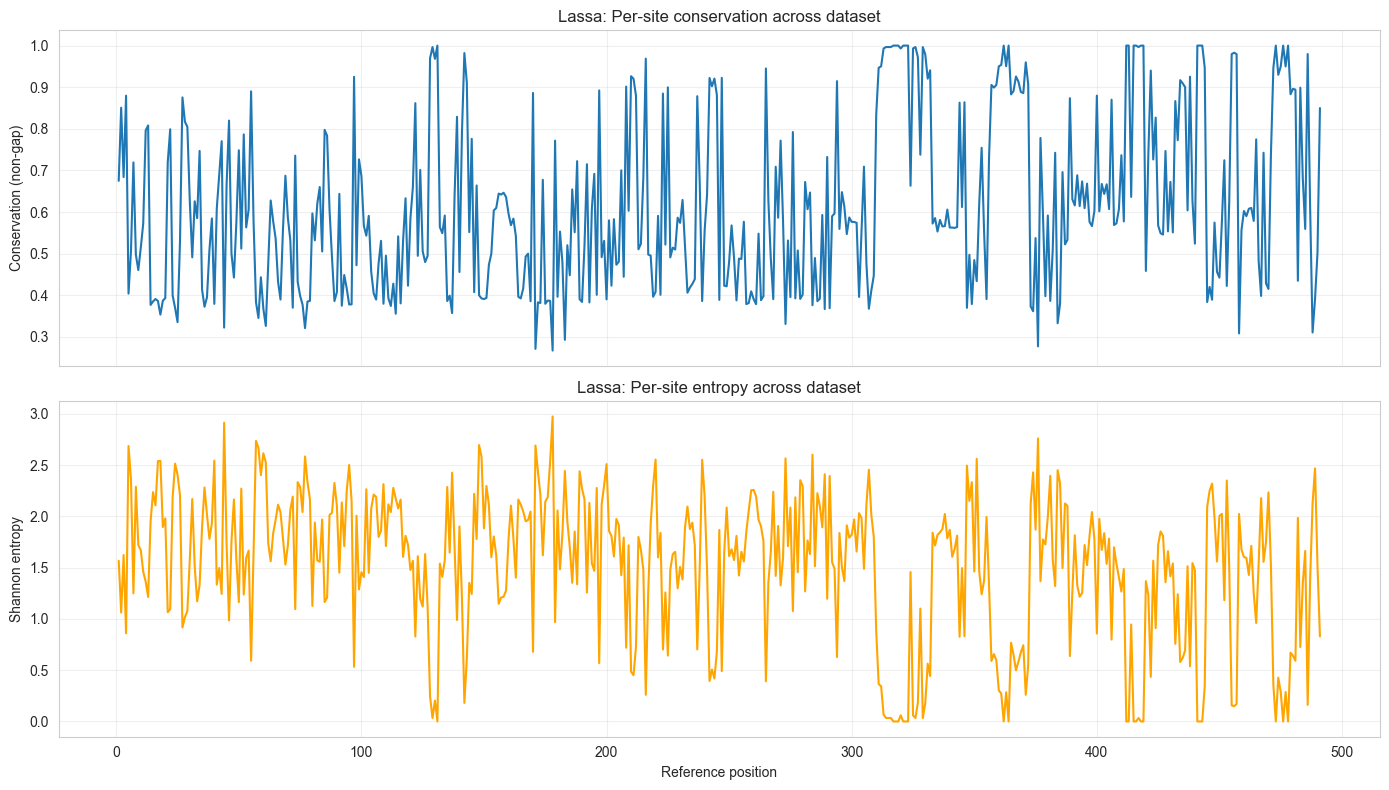

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
sns.lineplot(data=site_df, x="ref_pos", y="conservation", ax=ax)
ax.set_ylabel("Conservation (non-gap)")
ax.set_title("Lassa: Per-site conservation across dataset")
ax.grid(alpha=0.3)

ax = axes[1]
sns.lineplot(data=site_df, x="ref_pos", y="entropy", ax=ax, color="orange")
ax.set_xlabel("Reference position")
ax.set_ylabel("Shannon entropy")
ax.set_title("Lassa: Per-site entropy across dataset")
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "lassa_site_conservation_entropy.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path.resolve())
plt.show()

### 4.3 – Save site‑level table


In [12]:
out_site = OUT_DIR / "Lassa_site_scores_reference_based.csv"
site_df.to_csv(out_site, index=False)
print("Saved:", out_site.resolve())

Saved: /Users/user/data/results/lassa_step05A/Lassa_site_scores_reference_based.csv


## SECTION 5 – Substitution-level table (“A→V harmless vs A→D dangerous at ref_pos”)

Here we build a table of **all possible AA substitutions** at each reference position:
- For each `(ref_pos, ref_aa, alt_aa)` pair
- Compute:
  - BLOSUM62 score for ref→alt
  - A hybrid **impact score** combining:
    - alignment‑based conservation/entropy
    - substitution penalty (BLOSUM)


In [13]:
# BLOSUM62 table
BLOSUM62 = {
"A":{"A":4,"R":-1,"N":-2,"D":-2,"C":0,"Q":-1,"E":-1,"G":0,"H":-2,"I":-1,"L":-1,"K":-1,"M":-1,"F":-2,"P":-1,"S":1,"T":0,"W":-3,"Y":-2,"V":0},
"R":{"A":-1,"R":5,"N":0,"D":-2,"C":-3,"Q":1,"E":0,"G":-2,"H":0,"I":-3,"L":-2,"K":2,"M":-1,"F":-3,"P":-2,"S":-1,"T":-1,"W":-3,"Y":-2,"V":-3},
"N":{"A":-2,"R":0,"N":6,"D":1,"C":-3,"Q":0,"E":0,"G":0,"H":1,"I":-3,"L":-3,"K":0,"M":-2,"F":-3,"P":-2,"S":1,"T":0,"W":-4,"Y":-2,"V":-3},
"D":{"A":-2,"R":-2,"N":1,"D":6,"C":-3,"Q":0,"E":2,"G":-1,"H":-1,"I":-3,"L":-4,"K":-1,"M":-3,"F":-3,"P":-1,"S":0,"T":-1,"W":-4,"Y":-3,"V":-3},
"C":{"A":0,"R":-3,"N":-3,"D":-3,"C":9,"Q":-3,"E":-4,"G":-3,"H":-3,"I":-1,"L":-1,"K":-3,"M":-1,"F":-2,"P":-3,"S":-1,"T":-1,"W":-2,"Y":-2,"V":-1},
"Q":{"A":-1,"R":1,"N":0,"D":0,"C":-3,"Q":5,"E":2,"G":-2,"H":0,"I":-3,"L":-2,"K":1,"M":0,"F":-3,"P":-1,"S":0,"T":-1,"W":-2,"Y":-1,"V":-2},
"E":{"A":-1,"R":0,"N":0,"D":2,"C":-4,"Q":2,"E":5,"G":-2,"H":0,"I":-3,"L":-3,"K":1,"M":-2,"F":-3,"P":-1,"S":0,"T":-1,"W":-3,"Y":-2,"V":-2},
"G":{"A":0,"R":-2,"N":0,"D":-1,"C":-3,"Q":-2,"E":-2,"G":6,"H":-2,"I":-4,"L":-4,"K":-2,"M":-3,"F":-3,"P":-2,"S":0,"T":-2,"W":-2,"Y":-3,"V":-3},
"H":{"A":-2,"R":0,"N":1,"D":-1,"C":-3,"Q":0,"E":0,"G":-2,"H":8,"I":-3,"L":-3,"K":-1,"M":-2,"F":-1,"P":-2,"S":-1,"T":-2,"W":-2,"Y":2,"V":-3},
"I":{"A":-1,"R":-3,"N":-3,"D":-3,"C":-1,"Q":-3,"E":-3,"G":-4,"H":-3,"I":4,"L":2,"K":-3,"M":1,"F":0,"P":-3,"S":-2,"T":-1,"W":-3,"Y":-1,"V":3},
"L":{"A":-1,"R":-2,"N":-3,"D":-4,"C":-1,"Q":-2,"E":-3,"G":-4,"H":-3,"I":2,"L":4,"K":-2,"M":2,"F":0,"P":-3,"S":-2,"T":-1,"W":-2,"Y":-1,"V":1},
"K":{"A":-1,"R":2,"N":0,"D":-1,"C":-3,"Q":1,"E":1,"G":-2,"H":-1,"I":-3,"L":-2,"K":5,"M":-1,"F":-3,"P":-1,"S":0,"T":-1,"W":-3,"Y":-2,"V":-2},
"M":{"A":-1,"R":-1,"N":-2,"D":-3,"C":-1,"Q":0,"E":-2,"G":-3,"H":-2,"I":1,"L":2,"K":-1,"M":5,"F":0,"P":-2,"S":-1,"T":-1,"W":-1,"Y":-1,"V":1},
"F":{"A":-2,"R":-3,"N":-3,"D":-3,"C":-2,"Q":-3,"E":-3,"G":-3,"H":-1,"I":0,"L":0,"K":-3,"M":0,"F":6,"P":-4,"S":-2,"T":-2,"W":1,"Y":3,"V":-1},
"P":{"A":-1,"R":-2,"N":-2,"D":-1,"C":-3,"Q":-1,"E":-1,"G":-2,"H":-2,"I":-3,"L":-3,"K":-1,"M":-2,"F":-4,"P":7,"S":-1,"T":-1,"W":-4,"Y":-3,"V":-2},
"S":{"A":1,"R":-1,"N":1,"D":0,"C":-1,"Q":0,"E":0,"G":0,"H":-1,"I":-2,"L":-2,"K":0,"M":-1,"F":-2,"P":-1,"S":4,"T":1,"W":-3,"Y":-2,"V":-2},
"T":{"A":0,"R":-1,"N":0,"D":-1,"C":-1,"Q":-1,"E":-1,"G":-2,"H":-2,"I":-1,"L":-1,"K":-1,"M":-1,"F":-2,"P":-1,"S":1,"T":5,"W":-2,"Y":-2,"V":0},
"W":{"A":-3,"R":-3,"N":-4,"D":-4,"C":-2,"Q":-2,"E":-3,"G":-2,"H":-2,"I":-3,"L":-2,"K":-3,"M":-1,"F":1,"P":-4,"S":-3,"T":-2,"W":11,"Y":2,"V":-3},
"Y":{"A":-2,"R":-2,"N":-2,"D":-3,"C":-2,"Q":-1,"E":-2,"G":-3,"H":2,"I":-1,"L":-1,"K":-2,"M":-1,"F":3,"P":-3,"S":-2,"T":-2,"W":2,"Y":7,"V":-1},
"V":{"A":0,"R":-3,"N":-3,"D":-3,"C":-1,"Q":-2,"E":-2,"G":-3,"H":-3,"I":3,"L":1,"K":-2,"M":1,"F":-1,"P":-2,"S":-2,"T":0,"W":-3,"Y":-1,"V":4},
}

def blosum_score(ref_aa: str, alt_aa: str) -> float:
    if ref_aa not in BLOSUM62 or alt_aa not in BLOSUM62[ref_aa]:
        return 0.0
    return float(BLOSUM62[ref_aa][alt_aa])

def mutation_impact(row, alt_aa: str) -> float:
    """Hybrid impact score combining:
    - Alignment-based conservation
    - Entropy
    - BLOSUM62 penalty (ref -> alt)
    For now we do not include embedding distance explicitly (but we could later).
    Higher = more disruptive.
    """
    ref_aa = row["ref_aa"]
    cons = row["conservation"]  # high => constrained
    ent = row["entropy"]        # high => variable
    gap_rate = row["gap_rate"]

    if ref_aa not in AA_SET or alt_aa not in AA_SET:
        return 0.0

    # Normalised conservation/entropy
    cons_term = cons
    ent_term = ent / max(site_df["entropy"].max(), 1e-6)

    # BLOSUM penalty (negative scores are more disruptive)
    b = blosum_score(ref_aa, alt_aa)
    blosum_penalty = max(0.0, -b)  # e.g., -4 -> 4, +2 -> 0

    # Simple hybrid impact: weighted sum
    impact = 2.0 * cons_term + 1.0 * ent_term + 1.5 * blosum_penalty
    # Discount heavily gappy sites
    impact *= (1.0 - min(gap_rate, 0.8))
    return float(impact)

# Quick sanity example
example_row = site_df.iloc[0]
print("Example ref AA:", example_row["ref_aa"])
print("BLOSUM A->V (if ref=A,alt=V):", blosum_score("A","V"))
print("Example impact score (ref->V):", mutation_impact(example_row, "V"))

Example ref AA: M
BLOSUM A->V (if ref=A,alt=V): 0.0
Example impact score (ref->V): 0.9625343212459752


### 5.2 – Build full substitution-level table for Lassa (per ref_pos, per alt_aa)


In [14]:
mut_rows = []

for _, row in site_df.iterrows():
    ref_pos = int(row["ref_pos"])
    ref_aa = row["ref_aa"]
    if ref_aa not in AA_SET:
        continue

    for alt_aa in AAS:
        if alt_aa == ref_aa:
            continue  # skip identity
        b = blosum_score(ref_aa, alt_aa)
        impact = mutation_impact(row, alt_aa)
        mut_rows.append({
            "ref_pos": ref_pos,
            "ref_aa": ref_aa,
            "alt_aa": alt_aa,
            "blosum_score": b,
            "impact_score": impact,
            "site_conservation": row["conservation"],
            "site_entropy": row["entropy"],
            "site_gap_rate": row["gap_rate"],
            "site_category": row["site_category"],
        })

mut_df = pd.DataFrame(mut_rows)
print(mut_df.shape)
mut_df.head(10)

(9329, 9)


,ref_pos,ref_aa,alt_aa,blosum_score,impact_score,site_conservation,site_entropy,site_gap_rate,site_category
0,1,M,A,-1.0,1.731765,0.675,1.566804,0.487179,Intermediate
1,1,M,C,-1.0,1.731765,0.675,1.566804,0.487179,Intermediate
2,1,M,D,-3.0,3.270227,0.675,1.566804,0.487179,Intermediate
3,1,M,E,-2.0,2.500996,0.675,1.566804,0.487179,Intermediate
4,1,M,F,0.0,0.962534,0.675,1.566804,0.487179,Intermediate
5,1,M,G,-3.0,3.270227,0.675,1.566804,0.487179,Intermediate
6,1,M,H,-2.0,2.500996,0.675,1.566804,0.487179,Intermediate
7,1,M,I,1.0,0.962534,0.675,1.566804,0.487179,Intermediate
8,1,M,K,-1.0,1.731765,0.675,1.566804,0.487179,Intermediate
9,1,M,L,2.0,0.962534,0.675,1.566804,0.487179,Intermediate


### 5.3 – Plots: impact score distribution (Lassa)


Saved: /Users/user/data/results/lassa_step05A/figures/lassa_mutation_impact_distribution.png


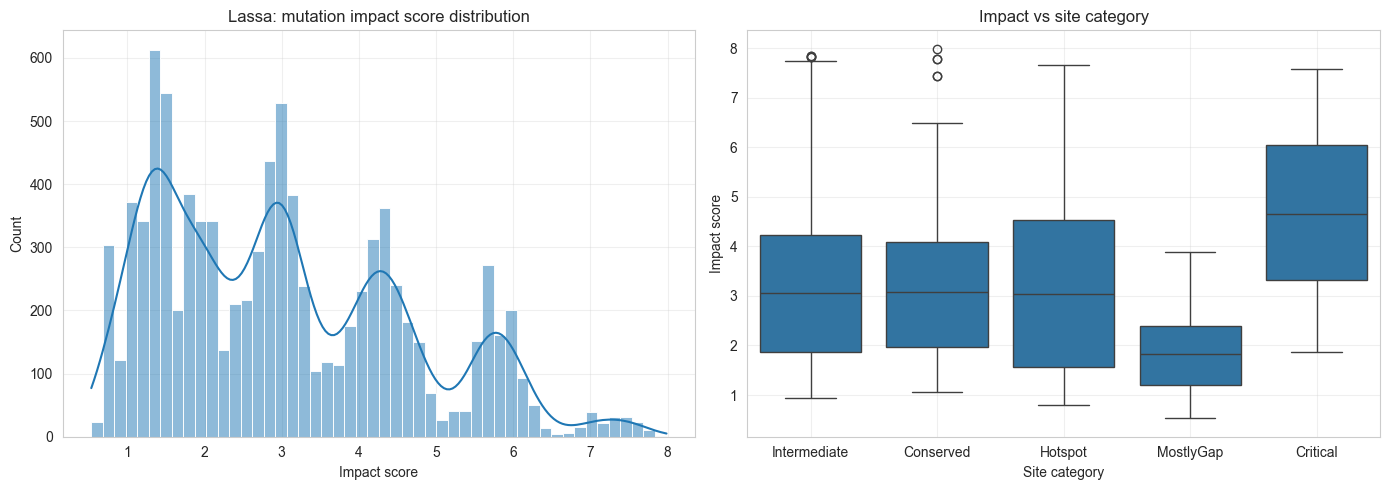

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.histplot(mut_df["impact_score"], bins=50, kde=True, ax=ax)
ax.set_title("Lassa: mutation impact score distribution")
ax.set_xlabel("Impact score")
ax.grid(alpha=0.3)

ax = axes[1]
sns.boxplot(x="site_category", y="impact_score", data=mut_df, ax=ax)
ax.set_title("Impact vs site category")
ax.set_xlabel("Site category")
ax.set_ylabel("Impact score")
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIG_DIR / "lassa_mutation_impact_distribution.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved:", fig_path.resolve())
plt.show()

### 5.4 – Save substitution-level table


In [16]:
out_mut = OUT_DIR / "Lassa_mutation_scores_reference_based.csv"
mut_df.to_csv(out_mut, index=False)
print("Saved:", out_mut.resolve())

Saved: /Users/user/data/results/lassa_step05A/Lassa_mutation_scores_reference_based.csv


## SECTION 6 – Summary (Lassa)

This notebook produced:
- **Site-level scores** per reference position:
  - gap rate, non-gap count, consensus AA, conservation, entropy
  - site category (Critical / Conserved / Hotspot / MostlyGap / Intermediate)
- **Substitution-level scores** per (ref_pos, ref_aa → alt_aa):
  - BLOSUM62 substitution score
  - Hybrid impact score

These will be used later to compare **Lassa vs Ebola** mutation landscapes in 05C.
